In [1]:
# Skipped in CI: Colab/bootstrap dependency install cell.


# Segment Analysis: Visualization

`SegmentTable` provides rich plotting features, specifically optimized for comparing spectra over multiple segments via `overlay_spectra()`.

The segment boundaries are still `gwpy.segments.Segment`, and the spectra being overlaid are GWpy `FrequencySeries` objects. gwexpy adds the table-oriented visualization layer by collecting those GWpy base classes in `SegmentTable` and providing overlay, color grading, and overview layouts on top. For the base relationship between GWpy classes and gwexpy extensions, see [SegmentTable: Basics](intro_segment_table.ipynb).


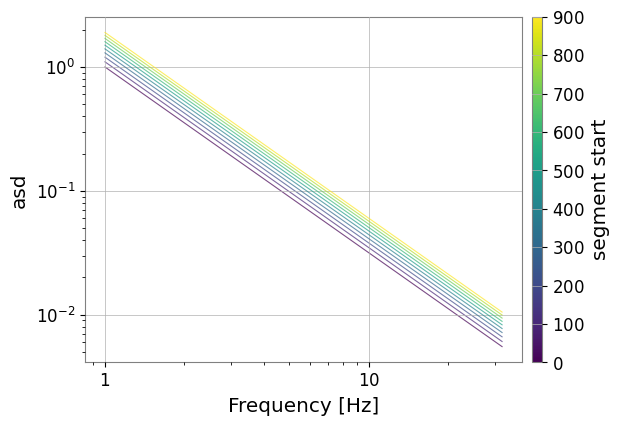

In [2]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import warnings

with warnings.catch_warnings():
    warnings.simplefilter('ignore')

    import numpy as np
    from gwpy.frequencyseries import FrequencySeries
    from gwpy.segments import Segment

    from gwexpy.table import SegmentTable

    def make_fs(i):
        f = np.linspace(1, 32, 256)
        data = (1.0/(f**1.5)) * (1.0 + i*0.1)
        return FrequencySeries(data, frequencies=f)

    segs = [Segment(i*100, i*100+100) for i in range(10)]
    st = SegmentTable.from_segments(segs, snr=np.random.uniform(5, 20, 10))
    st.add_series_column("asd", data=[make_fs(i) for i in range(10)], kind="frequencyseries")

    # 1. Overlay spectra graded by start time (default)
    plot = st.overlay_spectra("asd", color_by="t0")
    plot


## Color Grading by Meta Column

You can color individual lines based on any numeric meta column (e.g., SNR).

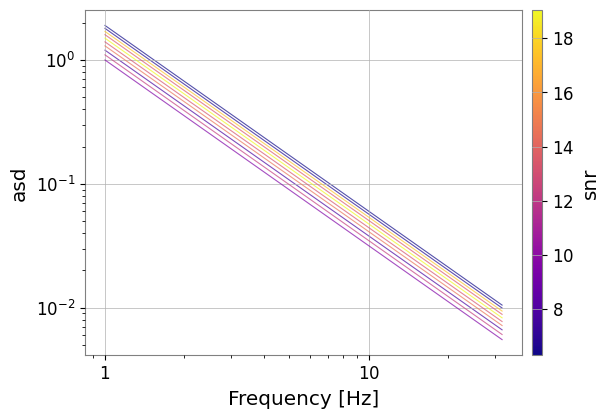

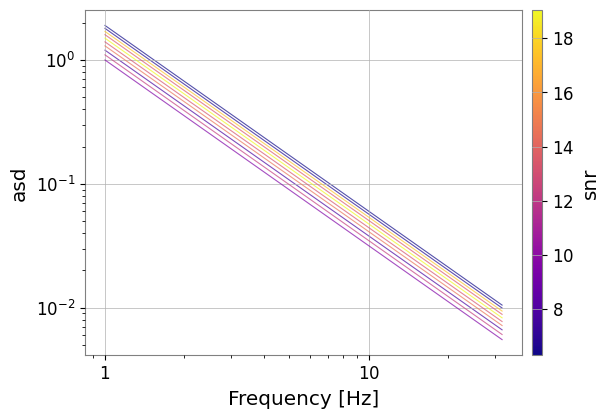

In [3]:
plot = st.overlay_spectra("asd", color_by="snr", cmap="plasma")
plot

## Overview Layouts

Use `segments()` to see the temporal layout of your table.

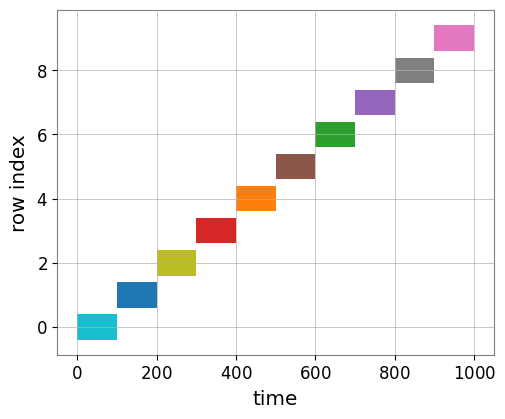

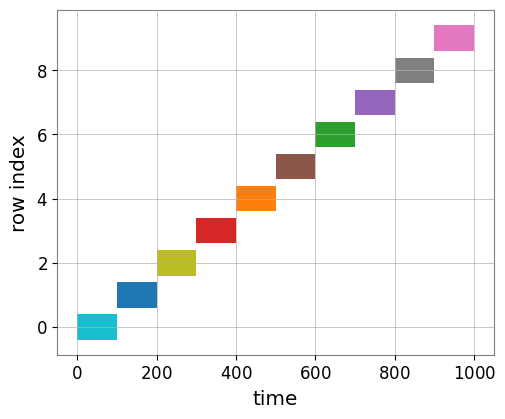

In [4]:
st.segments(color="snr")